In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# annotation and retantion codes
d = {
    24878: 'TG',
    24877: 'WT',
    24876: 'WT',
    24882: 'TG',
    24881: 'TG',
    24880: 'TG',
    24879: 'TG',
    24871: 'WT',
    24870: 'TG',
    24868: 'WT',
    24869: 'WT',
}

d_s = {
    24878: 'scene0',
    24877: 'scene0',
    24876: 'scene1', #meh
    24882: 'scene1',
    24881: 'scene0',
    24880: 'scene0',
    24879: 'scene1',
    24871: 'scene0',
    24870: 'scene1',
    24868: 'scene1',
    24869: 'scene1' #meh
}

# to_remove = [24871, 24882]
to_remove = []
# Assuming 0.65 is micrometers per pixel (not pixels per micrometer)
mum_per_pixel = 0.65
mum2_per_pixel = mum_per_pixel ** 2
mm_per_pixel = mum_per_pixel / 1000  # convert to mm per pixel
mm2_per_pixel = mm_per_pixel ** 2    # square millimeters per pixel

wt_color_border, wt_color_inner = '#069193', '#82C8C9'
tg_color_border, tg_color_inner = '#FE7D79', '#EFB4B2'
# font = 'Myriad Pro'  # 'Arial'

In [ ]:
# read data
df_f480 = pd.read_csv('kc_f480_spatial_data.csv')
df_vsig4 = pd.read_csv('kc_vsig4_spatial_data.csv')

# remove rows with ids in to_remove list
df_f480 = df_f480[~df_f480['id'].isin(to_remove)]
df_vsig4 = df_vsig4[~df_vsig4['id'].isin(to_remove)]

# control data from other experiment (not used in paper)
df_control = pd.read_csv('control_kc_zonation2.csv')

In [ ]:
# calculate proximity to central vein for each dataset
df_f480['proximity_to_central_vein'] = (df_f480['h0_median'] - df_f480['h1_median']) / df_f480['h0_median']
df_vsig4['proximity_to_central_vein'] = (df_vsig4['h0_median'] - df_vsig4['h1_median']) / df_vsig4['h0_median']
df_control['proximity_to_central_vein'] = (df_control['h0_median'] - df_control['h1_median']) / df_control['h0_median']

# annotate genotype for each dataset
df_f480['genotype'] = df_f480['id'].map(d)
df_vsig4['genotype'] = df_vsig4['id'].map(d)
df_control['genotype'] = 'External CTL'

# select only scenes from d_s
df_f480 = df_f480[df_f480.apply(lambda row: d_s.get(row['id'], None) == row['scene'], axis=1)]
df_vsig4 = df_vsig4[df_vsig4.apply(lambda row: d_s.get(row['id'], None) == row['scene'], axis=1)]

In [ ]:
# calculate number of KC per pixel for each dataset
df_f480['nb_kc_ppixel'] = df_f480['kc_nb'] / (df_f480['tissue_area'] - df_f480['hole_area'])
df_vsig4['nb_kc_ppixel'] = df_vsig4['kc_nb'] / (df_vsig4['tissue_area'] - df_vsig4['hole_area'])
df_control['nb_kc_ppixel'] = df_control['kc_nb'] / (df_control['tissue_area'] - df_control['hole_area'])

df_f480['nb_Vsig4_plus_ppixel'] = df_f480['f480_vsig4_plus_nb'] / (df_f480['tissue_area'] - df_f480['hole_area'])
df_f480['nb_Vsig4_minus_ppixel'] = df_f480['f480_vsig4_minus_nb'] / (df_f480['tissue_area'] - df_f480['hole_area'])


# Convert from KC per pixel to KC per square millimeter
df_f480['nb_kc_pmm2'] = df_f480['nb_kc_ppixel'] / mm2_per_pixel
df_vsig4['nb_kc_pmm2'] = df_vsig4['nb_kc_ppixel'] / mm2_per_pixel
df_control['nb_kc_pmm2'] = df_control['nb_kc_ppixel'] / mm2_per_pixel
df_f480['nb_Vsig4_plus_pmm2'] = df_f480['nb_Vsig4_plus_ppixel'] / mm2_per_pixel
df_f480['nb_Vsig4_minus_pmm2'] = df_f480['nb_Vsig4_minus_ppixel'] / mm2_per_pixel

# convert median kc_area to mum2
df_f480['median_kc_area'] = df_f480['median_kc_area'] * (mum_per_pixel ** 2)
df_vsig4['median_kc_area'] = df_vsig4['median_kc_area'] * (mum_per_pixel ** 2)
df_control['median_kc_area'] = df_control['median_kc_area'] * (mum_per_pixel ** 2)

## Counts

### F480+

/tmp/ipykernel_358820/3698859337.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/3698859337.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/3698859337.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


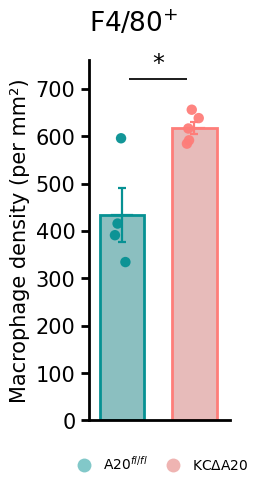

In [28]:
import matplotlib.patches as mpatches

# colors
wt_color_border, wt_color_inner = '#069193', '#82C8C9'
tg_color_border, tg_color_inner = '#FE7D79', '#EFB4B2'

order = ['WT', 'TG']
palette_inner = {'WT': wt_color_inner, 'TG': tg_color_inner}
border_map   = {'WT': wt_color_border, 'TG': tg_color_border}

fig, ax = plt.subplots(1, 1, figsize=(2.5, 5))

sns.barplot(
    data=df_f480, x='genotype', y='nb_kc_pmm2',
    order=order, palette=palette_inner,
    errorbar=None, edgecolor='none', linewidth=0, ax=ax, ci=None
)

# --- Adjust width and spacing ---
bar_width = 0.45   # narrower bars (default ~0.8)
spacing = 0.73     # increases distance between categories
positions = np.arange(len(order)) * (1*spacing)

for i, bar in enumerate(ax.patches):
    g = order[i]
    # set new x-position and narrower width
    bar.set_x(positions[i] - bar_width/2)
    bar.set_width(bar_width)
    # recolor borders
    bar.set_edgecolor(border_map[g])
    bar.set_linewidth(2)

# Reposition x-ticks
ax.set_xticks(positions)
ax.set_xticklabels(order)


# --- Dots (now matching border colors) ---
sns.stripplot(
    data=df_f480, x='genotype', y='nb_kc_pmm2',
    order=order, palette=border_map,   # <-- use border_map here
    ax=ax, jitter=0.12, size=7.5, edgecolor='none', linewidth=0.8, alpha=0.95
)

# Match dot positions to shifted bars
for coll, pos in zip(ax.collections, positions):
    offsets = coll.get_offsets()
    offsets[:, 0] = pos + np.random.uniform(-0.08, 0.08, len(offsets))
    coll.set_offsets(offsets)

# --- Style ---
ax.set_ylabel('Macrophage density (per mm²)', fontsize=15)
ax.set_ylim(bottom=0)

# thicker axes like the example
for s in ['top', 'right']:
    ax.spines[s].set_visible(False)
ax.spines['left'].set_linewidth(2.0)
ax.spines['bottom'].set_linewidth(2.0)

# thicker y ticks, no x ticks/labels
ax.tick_params(axis='y', labelsize=15, width=2.0, length=6)
ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)

# keep tight x-limits
ax.set_xlim(positions[0] - bar_width*0.75,
            positions[-1] + bar_width*0.8)
ax.set_xlabel(None)


# --- Legend ---
legend_handles = [
    plt.Line2D([], [], marker='o', color='none',
               markerfacecolor=palette_inner['WT'], markeredgecolor='none',
               markersize=10, label='A20$^{fl/fl}$'),
    plt.Line2D([], [], marker='o', color='none',
               markerfacecolor=palette_inner['TG'], markeredgecolor='none',
               markersize=10, label='KC$\Delta$A20'),
]
ax.legend(handles=legend_handles, frameon=False, loc='upper left',
          bbox_to_anchor=(0, 1), ncol=2, handletextpad=0.4, columnspacing=0.5)

# ... your width/spacing code unchanged ...

# --- Custom error bars at shifted positions ---
stats = (df_f480.groupby('genotype')['nb_kc_pmm2']
         .agg(mean='mean', sem='sem').reindex(order))
means = stats['mean'].to_numpy()
sems  = stats['sem'].to_numpy()

# colors for each group (match borders)
ecolors = [border_map[g] for g in order]
for x0, m, s, c in zip(positions, means, sems, ecolors):
    ax.errorbar(x0, m, yerr=s, fmt='none', ecolor=c, elinewidth=1.6, capsize=3, capthick=1.6)
    # thin mean line to mimic "cap" look
    ax.plot([x0 - bar_width*0.22, x0 + bar_width*0.22], [m, m], color=c, lw=1.6)

from scipy.stats import ttest_ind

from matplotlib.lines import Line2D

# p-value
wt = df_f480.loc[df_f480['genotype']=='WT','nb_kc_pmm2'].dropna()
tg = df_f480.loc[df_f480['genotype']=='TG','nb_kc_pmm2'].dropna()
p = ttest_ind(wt, tg, equal_var=False).pvalue

def p_to_stars(p):
    return ('ns' if p>=0.05 else
            '*' if p>=0.01 else
            '**' if p>=0.001 else
            '***' if p>=1e-4 else '****')

# y position just above the highest mean±SEM
ymin, ymax = ax.get_ylim()
yr = ymax - ymin
y_top = float((means + sems).max())
pad = 0.13 * yr                      # vertical padding above bars
y = y_top + pad                      # y for the horizontal bar

# make sure it fits
ax.set_ylim(top=max(ymax, y + 0.06*yr))

# horizontal significance line only (no vertical lines)
x1, x2 = positions[0] + 0.075 , positions[1] - 0.075
ax.plot([x1, x2], [y, y], lw=1.25, c='black', solid_capstyle='butt')

# stars centered above the line
ax.text((x1+x2)/2, y + 0.012*yr, p_to_stars(p),
        ha='center', va='bottom', fontsize=17)

# --- Legend at the bottom ---
legend_handles = [
    plt.Line2D([], [], marker='o', color='none',
               markerfacecolor=palette_inner['WT'], markeredgecolor='none',
               markersize=10, label='A20$^{fl/fl}$'),
    plt.Line2D([], [], marker='o', color='none',
               markerfacecolor=palette_inner['TG'], markeredgecolor='none',
               markersize=10, label='KC$\Delta$A20'),
]
ax.legend(handles=legend_handles, frameon=False,
          loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=2,
          handletextpad=0.4, columnspacing=0.8)




ax.set_title(
    'F4/80$^{+}$',
    fontsize=19,           # same as y-label
    fontweight='normal',   # not bold, to match paper style
    loc='left',            # left-align like the example
    pad=20          # minimal spacing above axis
)


# leave room for the bottom legend
# plt.subplots_adjust(bottom=0.18)
plt.tight_layout()
plt.savefig('final_plots/f480_plus.pdf', dpi=300, bbox_inches='tight')

plt.show()


### F480+/Clec4f-

In [8]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# ====== shared colors (same as your total plot) ======
wt_color_border, wt_color_inner = '#069193', '#82C8C9'
tg_color_border, tg_color_inner = '#FE7D79', '#EFB4B2'
order = ['WT', 'TG']
palette_inner = {'WT': wt_color_inner, 'TG': tg_color_inner}
border_map   = {'WT': wt_color_border, 'TG': tg_color_border}

def paper_panel(df, value_col, title_text, ylabel='Macrophage density (per mm²)',
                fig_size=(2.5, 5), bar_width=0.45, spacing=0.73,
                star_fontsize=17, title_fontsize=19):
    """
    df: dataframe containing columns ['genotype', value_col]
    value_col: column to plot (e.g., 'nb_Vsig4_minus_pmm2' or 'nb_Vsig4_plus_pmm2')
    title_text: LaTeX-friendly title string
    """
    # build per your previous code
    fig, ax = plt.subplots(1, 1, figsize=fig_size)

    # --- Bars (inner colors) ---
    sns.barplot(
        data=df.rename(columns={value_col: 'nb_kc_pmm2'}),
        x='genotype', y='nb_kc_pmm2',
        order=order, palette=palette_inner,
        errorbar=None, edgecolor='none', linewidth=0, ax=ax, ci=None
    )

    # --- Adjust width & spacing ---
    positions = np.arange(len(order)) * (1*spacing)
    for i, bar in enumerate(ax.patches):
        g = order[i]
        bar.set_x(positions[i] - bar_width/2)
        bar.set_width(bar_width)
        bar.set_edgecolor(border_map[g])
        bar.set_linewidth(2)

    # --- Dots (match border colors) ---
    sns.stripplot(
        data=df.rename(columns={value_col: 'nb_kc_pmm2'}),
        x='genotype', y='nb_kc_pmm2',
        order=order, palette=border_map,
        ax=ax, jitter=0.12, size=7.5, edgecolor='none', linewidth=0, alpha=0.95
    )
    # align dot x to shifted bar centers
    for coll, pos in zip(ax.collections, positions):
        offs = coll.get_offsets()
        offs[:, 0] = pos + np.random.uniform(-0.08, 0.08, len(offs))
        coll.set_offsets(offs)

    # --- Style ---
    ax.set_ylabel(ylabel, fontsize=15)
    ax.set_ylim(bottom=0)
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.tick_params(axis='y', labelsize=15, width=2.0, length=6)
    ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    ax.set_xlim(positions[0] - bar_width*0.75, positions[-1] + bar_width*0.8)
    ax.set_xlabel(None)

    # --- Legend bottom ---
    legend_handles = [
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['WT'], markeredgecolor='none',
                   markersize=10, label='A20$^{fl/fl}$'),
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['TG'], markeredgecolor='none',
                   markersize=10, label='KC$\Delta$A20'),
    ]
    ax.legend(handles=legend_handles, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=2,
              handletextpad=0.4, columnspacing=0.8)

    # --- Custom error bars (SEM) ---
    tmp = df[['genotype', value_col]].rename(columns={value_col: 'nb_kc_pmm2'})
    stats = (tmp.groupby('genotype')['nb_kc_pmm2']
             .agg(mean='mean', sem='sem').reindex(order))
    means = stats['mean'].to_numpy()
    sems  = stats['sem'].to_numpy()
    ecolors = [border_map[g] for g in order]
    for x0, m, s, c in zip(positions, means, sems, ecolors):
        ax.errorbar(x0, m, yerr=s, fmt='none', ecolor=c, elinewidth=1.6, capsize=3, capthick=1.6)
        ax.plot([x0 - bar_width*0.22, x0 + bar_width*0.22], [m, m], color=c, lw=1.6)

    # --- Significance (horizontal line only) ---
    wt = tmp.loc[tmp['genotype']=='WT','nb_kc_pmm2'].dropna()
    tg = tmp.loc[tmp['genotype']=='TG','nb_kc_pmm2'].dropna()
    p = ttest_ind(wt, tg, equal_var=False).pvalue
    def p_to_stars(p):
        return ('ns' if p>=0.05 else
                '*'  if p>=0.01 else
                '**' if p>=0.001 else
                '***' if p>=1e-4 else '****')
    ymin, ymax = ax.get_ylim()
    yr = ymax - ymin
    y_top = float((means + sems).max())
    pad = 0.13 * yr
    y = y_top + pad
    ax.set_ylim(top=max(ymax, y + 0.06*yr))
    x1, x2 = positions[0] + 0.075 , positions[1] - 0.075
    ax.plot([x1, x2], [y, y], lw=1.25, c='black', solid_capstyle='butt')
    ax.text((x1+x2)/2, y + 0.012*yr, p_to_stars(p),
            ha='center', va='bottom', fontsize=star_fontsize)

    # --- Title (left, a bit higher) ---
    ax.set_title(title_text, fontsize=title_fontsize,
                 fontweight='normal', loc='left', pad=20)

    plt.subplots_adjust(bottom=0.18)
    plt.tight_layout()
    return fig, ax


In [24]:
df_f480 = df_f480.iloc[:-1]

/tmp/ipykernel_358820/1698204105.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/1698204105.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/1698204105.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


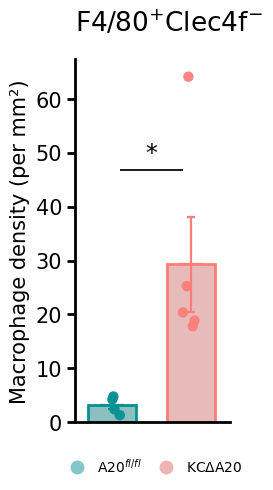

In [27]:
# 1) F4/80+ / Clec4f-  (Vsig4-)
fig_minus, ax_minus = paper_panel(
    df_f480[['genotype', 'nb_Vsig4_minus_pmm2']].copy(),
    value_col='nb_Vsig4_minus_pmm2',
    title_text='F4/80$^{+}$Clec4f$^{-}$'
)
fig_minus.savefig('f480_clec4f_minus.pdf', dpi=300, bbox_inches='tight')



### F480+/Clec4f+

/tmp/ipykernel_358820/1698204105.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/1698204105.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipykernel_358820/1698204105.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(


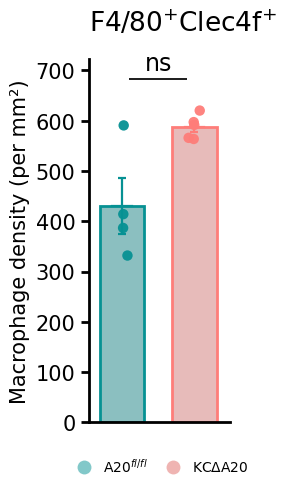

In [29]:
# 2) F4/80+ / Clec4f+  (Vsig4+)
fig_plus, ax_plus = paper_panel(
    df_f480[['genotype', 'nb_Vsig4_plus_pmm2']].copy(),
    value_col='nb_Vsig4_plus_pmm2',
    title_text='F4/80$^{+}$Clec4f$^{+}$'
)
fig_plus.savefig('f480_clec4f_plus.pdf', dpi=300, bbox_inches='tight')


In [42]:
def paper_panel(df, value_col, title_text,
                fig_size=(2.5, 5)):         # <- no ylim param
    fig, ax = plt.subplots(1, 1, figsize=fig_size)

    # ---- prepare data (same as before) ----
    tmp0 = df[['genotype', value_col]].copy()
    def _coerce_1d_numeric(series):
        def to_scalar(v):
            if isinstance(v, (list, tuple, np.ndarray)):
                a = np.array(v).squeeze()
                return float(a.flat[0])
            return v
        out = series.apply(to_scalar)
        return pd.to_numeric(out, errors='coerce')
    tmp0[value_col] = _coerce_1d_numeric(tmp0[value_col])
    tmp = tmp0.rename(columns={value_col: 'nb_kc_pmm2'})

    # ---- bars (inner colors) ----
    sns.barplot(data=tmp, x='genotype', y='nb_kc_pmm2',
                order=order, palette=palette_inner,
                errorbar=None, edgecolor='none', linewidth=0, ax=ax, ci=None)

    bar_width, spacing = 0.45, 0.73
    positions = np.arange(len(order)) * spacing
    for i, bar in enumerate(ax.patches):
        g = order[i]
        bar.set_x(positions[i] - bar_width/2)
        bar.set_width(bar_width)
        bar.set_edgecolor(border_map[g])
        bar.set_linewidth(2)

    # ---- dots (border colors) ----
    sns.stripplot(data=tmp, x='genotype', y='nb_kc_pmm2',
                  order=order, palette=border_map,
                  ax=ax, jitter=0.12, size=7.5, edgecolor='none', linewidth=0, alpha=0.95)
    for coll, pos in zip(ax.collections, positions):
        off = coll.get_offsets()
        off[:, 0] = pos + np.random.uniform(-0.08, 0.08, len(off))
        coll.set_offsets(off)

    # ---- style ----
    ax.set_ylabel('Macrophage density (per mm²)', fontsize=15)
    ax.set_ylim(bottom=0)   # bottom fixed at 0; top will be set per-plot below
    for s in ['top', 'right']: ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.tick_params(axis='y', labelsize=15, width=2.0, length=6)
    ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    ax.set_xlim(positions[0] - bar_width*0.75, positions[-1] + bar_width*0.8)
    ax.set_xlabel(None)

    # ---- legend bottom ----
    legend_handles = [
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['WT'], markersize=10,
                   label='A20$^{fl/fl}$'),
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['TG'], markersize=10,
                   label='KC$\Delta$A20'),
    ]
    ax.legend(handles=legend_handles, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.06), ncol=2,
              handletextpad=0.4, columnspacing=0.8)

    # ---- SEM bars ----
    stats = (tmp.groupby('genotype')['nb_kc_pmm2']
             .agg(mean='mean', sem='sem').reindex(order))
    means, sems = stats['mean'].to_numpy(), stats['sem'].to_numpy()
    for x0, m, s, c in zip(positions, means, sems, [border_map[g] for g in order]):
        ax.errorbar(x0, m, yerr=s, fmt='none', ecolor=c, elinewidth=1.6, capsize=3, capthick=1.6)
        ax.plot([x0 - bar_width*0.22, x0 + bar_width*0.22], [m, m], color=c, lw=1.6)

    # ---- significance (horizontal line; per-plot scaling) ----
    from scipy.stats import ttest_ind
    wt = tmp.loc[tmp['genotype']=='WT', 'nb_kc_pmm2'].dropna()
    tg = tmp.loc[tmp['genotype']=='TG', 'nb_kc_pmm2'].dropna()
    p  = ttest_ind(wt, tg, equal_var=False).pvalue
    def p_to_stars(p):
        return ('ns' if p>=0.05 else '*' if p>=0.01 else
                '**' if p>=0.001 else '***' if p>=1e-4 else '****')

    data_top = float((means + sems).max())
    pad      = 0.13 * max(data_top, 1e-9)      # padding scales with this panel’s data
    y_line   = data_top + pad
    ax.set_ylim(top=y_line + 0.06 * max(data_top, 1e-9))  # ensure room for line+stars

    x1, x2 = positions[0] + 0.075, positions[1] - 0.075
    ax.plot([x1, x2], [y_line, y_line], lw=1.25, c='black', solid_capstyle='butt')
    ax.text((x1+x2)/2, y_line + 0.012*max(data_top, 1e-9),
            p_to_stars(p), ha='center', va='bottom', fontsize=17)

    # ---- title ----
    ax.set_title(title_text, fontsize=19, fontweight='normal', loc='left', pad=20)

    # fixed margins for identical physical size across panels
    plt.subplots_adjust(left=0.22, right=0.98, top=0.92, bottom=0.18)
    # DO NOT use bbox_inches='tight' if you want identical page sizes
    return fig, ax


/tmp/ipykernel_143591/3792549689.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tmp, x='genotype', y='nb_kc_pmm2',
/tmp/ipykernel_143591/3792549689.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tmp, x='genotype', y='nb_kc_pmm2',
/tmp/ipykernel_143591/3792549689.py:33: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(data=tmp, x='genotype', y='nb_kc_pmm2',
/tmp/ipykernel_143591/3792549689.py:19: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=tmp, x='genotype', y='nb_kc_pmm2',
/tmp/ipykernel_143591/3792549689.py:19: FutureWarning: 

Passing `pale

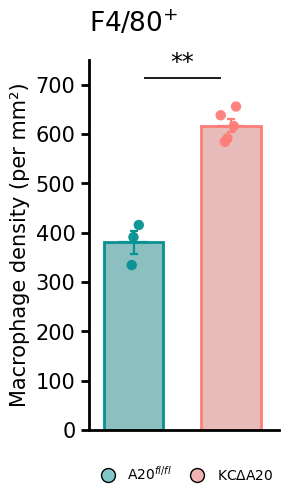

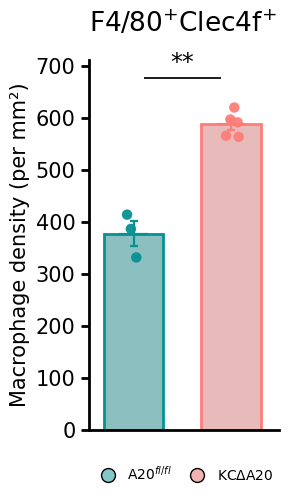

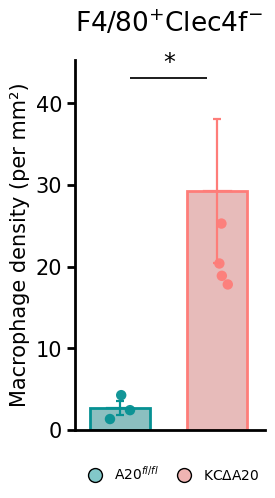

In [43]:
fig_total, ax_total = paper_panel(df_f480, 'nb_kc_pmm2',             'F4/80$^{+}$')
fig_total.savefig('f480_total_noshare.pdf', dpi=300)  # no bbox_inches='tight'

fig_plus,  ax_plus  = paper_panel(df_f480, 'nb_Vsig4_plus_pmm2',     'F4/80$^{+}$Clec4f$^{+}$')
fig_plus.savefig('f480_clec4f_plus_noshare.pdf', dpi=300)

fig_minus, ax_minus = paper_panel(df_f480, 'nb_Vsig4_minus_pmm2',    'F4/80$^{+}$Clec4f$^{-}$')
fig_minus.savefig('f480_clec4f_minus_noshare.pdf', dpi=300)


## Zonation

In [ ]:
zonation_df = pd.read_csv('kc_zonation_spatial_data.csv')
# to_remove = [24871, 24882, 24869]
to_remove = [24869]

zonation_df = zonation_df[~zonation_df['id'].isin(to_remove)]
zonation_df['F480_proximity_to_central_vein'] = (zonation_df['h0_median'] - zonation_df['h1_median']) / zonation_df['h0_median']
zonation_df['F480_Clec4fplus_proximity_to_central_vein'] = (zonation_df['h0_median'] - zonation_df['h1_median_plus']) / zonation_df['h0_median']
zonation_df['F480_Clec4fminus_proximity_to_central_vein'] = (zonation_df['h0_median'] - zonation_df['h1_median_min']) / zonation_df['h0_median']
zonation_df['genotype'] = zonation_df['id'].map(d)

# select only scenes from d_s
zonation_df = zonation_df[zonation_df.apply(lambda row: d_s.get(row['id'], None) == row['scene'], axis=1)]
zonation_df.to_csv('mac_proximity_to_cv.csv', index=False)


### Share y

In [32]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

# --- Colors (consistent with your density figures) ---
wt_color_border, wt_color_inner = '#069193', '#82C8C9'
tg_color_border, tg_color_inner = '#FE7D79', '#EFB4B2'
order = ['WT', 'TG']
palette_inner = {'WT': wt_color_inner, 'TG': tg_color_inner}
border_map    = {'WT': wt_color_border, 'TG': tg_color_border}
font = ''


def _coerce_1d_numeric(series):
    def to_scalar(v):
        if isinstance(v, (list, tuple, np.ndarray)):
            a = np.array(v).squeeze()
            return float(a.flat[0])
        return v
    return pd.to_numeric(series.apply(to_scalar), errors='coerce')


def paper_panel_box_shared(df, value_col, title_text, shared_ylim, fig_size=(2.5, 5), alternative = 'two-sided'):
    """
    Draws a boxplot in paper style (used for F4/80+, Clec4f+, Clec4f− proximity)
    with shared y-limits across all panels.
    """
    tmp = df[['genotype', value_col]].copy()
    tmp[value_col] = _coerce_1d_numeric(tmp[value_col])
    tmp = tmp.rename(columns={value_col: 'y'})

    fig, ax = plt.subplots(1, 1, figsize=fig_size)

    # --- Boxplot ---
    sns.boxplot(
        data=tmp, x='genotype', y='y', order=order,
        palette=[palette_inner[g] for g in order],
        ax=ax, width=0.45, fliersize=3, linewidth=1.8
    )

    # Color edges per genotype
    for patch, g in zip(ax.artists, order):
        patch.set_edgecolor(border_map[g])
        patch.set_linewidth(2)
    for i, g in enumerate(order):
        for line in ax.lines[i*6:(i+1)*6]:
            line.set_color(border_map[g])
            line.set_linewidth(1.6)

    # Overlay dots
    sns.stripplot(
        data=tmp, x='genotype', y='y', order=order,
        palette=border_map, ax=ax, jitter=0.12, size=6,
        edgecolor='none', alpha=0.9
    )

    # --- Style ---
    ax.set_ylabel('Macrophage proximity to Glul', fontsize=15)
    ax.set_ylim(shared_ylim)
    for s in ['top', 'right']:
        ax.spines[s].set_visible(False)
    ax.spines['left'].set_linewidth(2.0)
    ax.spines['bottom'].set_linewidth(2.0)
    ax.tick_params(axis='y', labelsize=15, width=2.0, length=6)
    ax.tick_params(axis='x', bottom=False, top=False, labelbottom=False)
    ax.set_xlabel(None)

    # --- Significance line (shared y-limits; do NOT change ylim) ---
    wt = tmp.loc[tmp['genotype']=='WT','y'].dropna()
    tg = tmp.loc[tmp['genotype']=='TG','y'].dropna()
    p  = ttest_ind(wt, tg, equal_var=True, alternative=alternative).pvalue

    def p_to_stars(p):
        return ('ns' if p>=0.05 else
                '*'  if p>=0.01 else
                '**' if p>=0.001 else
                '***' if p>=1e-4 else '****')

    ymin, ymax = shared_ylim
    yr = ymax - ymin

    # draw the bracket a bit below the top, inside the shared range
    y_line   = ymax - 0.12*yr          # horizontal line position
    star_y   = y_line + 0.02*yr        # stars slightly above the line (still inside)

    x1, x2 = 0 + 0.075, 1 - 0.075
    ax.plot([x1, x2], [y_line, y_line], lw=1.25, c='black', solid_capstyle='butt')
    ax.text(0.5, star_y, p_to_stars(p), ha='center', va='bottom', fontsize=17)

    # IMPORTANT: keep the shared y-limits intact
    ax.set_ylim(shared_ylim)

    # --- Legend bottom ---
    legend_handles = [
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['WT'], markersize=10, label='A20$^{fl/fl}$'),
        plt.Line2D([], [], marker='o', color='none',
                   markerfacecolor=palette_inner['TG'], markersize=10, label='KC$\Delta$A20'),
    ]
    ax.legend(handles=legend_handles, frameon=False,
              loc='upper center', bbox_to_anchor=(0.5, -0.06),
              ncol=2, handletextpad=0.4, columnspacing=0.8)

    # --- Title ---
    ax.set_title(title_text, fontsize=21, fontweight='normal', loc='left', pad=20)

    plt.subplots_adjust(left=0.22, right=0.98, top=0.92, bottom=0.18)
    plt.tight_layout()
    return fig, ax

Shared ylim: (np.float64(-1.4568980211150142), np.float64(0.8902118614060723))


/tmp/ipykernel_358820/742970520.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_358820/742970520.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_358820/742970520.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_358820/742970520.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_358820/742970520.py:37: FutureWar

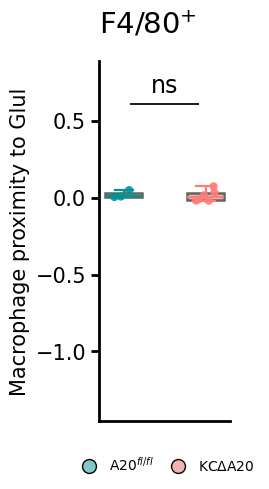

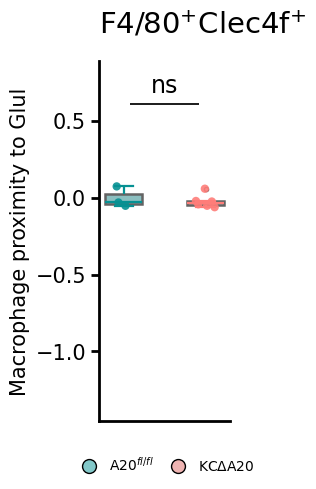

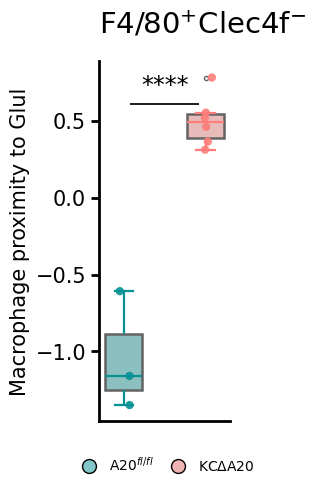

In [33]:
# ────────────────────────────────────────────────
#  Compute shared y-axis limits across all 3 panels
# ────────────────────────────────────────────────
ymin = min(
    zonation_df['F480_proximity_to_central_vein'].min(),
    zonation_df['F480_Clec4fplus_proximity_to_central_vein'].min(),
    zonation_df['F480_Clec4fminus_proximity_to_central_vein'].min()
)
ymax = max(
    zonation_df['F480_proximity_to_central_vein'].max(),
    zonation_df['F480_Clec4fplus_proximity_to_central_vein'].max(),
    zonation_df['F480_Clec4fminus_proximity_to_central_vein'].max()
)
shared_ylim = (ymin - 0.05*(ymax - ymin), ymax + 0.05*(ymax - ymin))

print("Shared ylim:", shared_ylim)

# ────────────────────────────────────────────────
#  1. F4/80⁺ total proximity
# ────────────────────────────────────────────────
fig_total, ax_total = paper_panel_box_shared(
    zonation_df, 'F480_proximity_to_central_vein', 
    title_text='F4/80$^{+}$', shared_ylim=shared_ylim
)
fig_total.savefig('f480_total_proximity_shared.pdf', dpi=300, bbox_inches='tight')

# ────────────────────────────────────────────────
#  2. F4/80⁺ Clec4f⁺ proximity
# ────────────────────────────────────────────────
fig_plus, ax_plus = paper_panel_box_shared(
    zonation_df, 'F480_Clec4fplus_proximity_to_central_vein',
    title_text='F4/80$^{+}$Clec4f$^{+}$', shared_ylim=shared_ylim
)
fig_plus.savefig('f480_clec4f_plus_proximity_shared.pdf', dpi=300, bbox_inches='tight')

# ────────────────────────────────────────────────
#  3. F4/80⁺ Clec4f⁻ proximity
# ────────────────────────────────────────────────
fig_minus, ax_minus = paper_panel_box_shared(
    zonation_df, 'F480_Clec4fminus_proximity_to_central_vein',
    title_text='F4/80$^{+}$Clec4f$^{-}$', shared_ylim=shared_ylim,
    alternative='less'  # one-sided test for Clec4f−
)
fig_minus.savefig('f480_clec4f_minus_proximity_shared.pdf', dpi=300, bbox_inches='tight')

Shared ylim: (np.float64(-1.4568980211150142), np.float64(0.8902118614060723))


/tmp/ipykernel_343339/194821480.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_343339/194821480.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_343339/194821480.py:36: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_343339/194821480.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.stripplot(
/tmp/ipykernel_343339/194821480.py:36: FutureWar

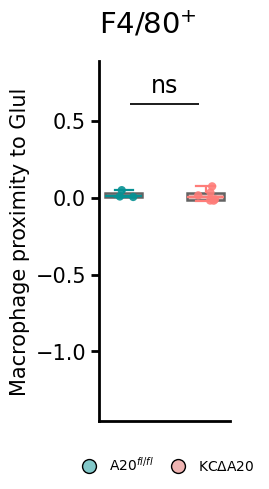

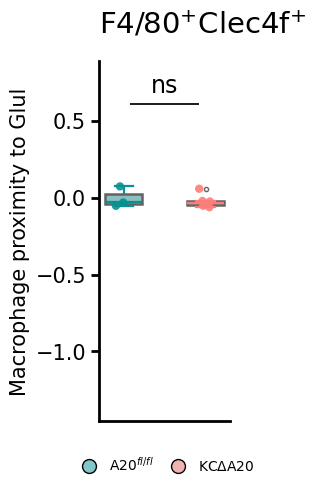

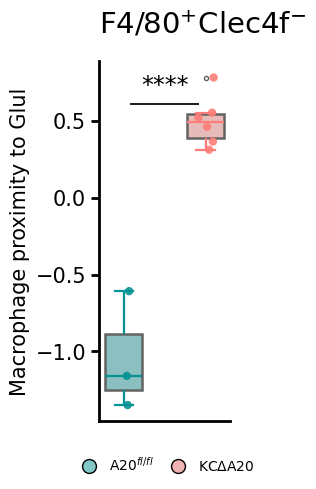

In [14]:
# ────────────────────────────────────────────────
#  Compute shared y-axis limits across all 3 panels
# ────────────────────────────────────────────────
ymin = min(
    zonation_df['F480_proximity_to_central_vein'].min(),
    zonation_df['F480_Clec4fplus_proximity_to_central_vein'].min(),
    zonation_df['F480_Clec4fminus_proximity_to_central_vein'].min()
)
ymax = max(
    zonation_df['F480_proximity_to_central_vein'].max(),
    zonation_df['F480_Clec4fplus_proximity_to_central_vein'].max(),
    zonation_df['F480_Clec4fminus_proximity_to_central_vein'].max()
)
shared_ylim = (ymin - 0.05*(ymax - ymin), ymax + 0.05*(ymax - ymin))

print("Shared ylim:", shared_ylim)

# ────────────────────────────────────────────────
#  1. F4/80⁺ total proximity
# ────────────────────────────────────────────────
fig_total, ax_total = paper_panel_box_shared(
    zonation_df, 'F480_proximity_to_central_vein', 
    title_text='F4/80$^{+}$', shared_ylim=shared_ylim
)
fig_total.savefig('f480_total_proximity_shared.pdf', dpi=300)

# ────────────────────────────────────────────────
#  2. F4/80⁺ Clec4f⁺ proximity
# ────────────────────────────────────────────────
fig_plus, ax_plus = paper_panel_box_shared(
    zonation_df, 'F480_Clec4fplus_proximity_to_central_vein',
    title_text='F4/80$^{+}$Clec4f$^{+}$', shared_ylim=shared_ylim
)
fig_plus.savefig('f480_clec4f_plus_proximity_shared.pdf', dpi=300)

# ────────────────────────────────────────────────
#  3. F4/80⁺ Clec4f⁻ proximity
# ────────────────────────────────────────────────
fig_minus, ax_minus = paper_panel_box_shared(
    zonation_df, 'F480_Clec4fminus_proximity_to_central_vein',
    title_text='F4/80$^{+}$Clec4f$^{-}$', shared_ylim=shared_ylim
)
fig_minus.savefig('f480_clec4f_minus_proximity_shared.pdf', dpi=300)

In [15]:
zonation_df[['id', 'scene', 'F480_Clec4fminus_proximity_to_central_vein', 'genotype']]

,id,scene,F480_Clec4fminus_proximity_to_central_vein,genotype
1,24868,scene1,-0.608168,WT
5,24870,scene1,0.554750,TG
7,24871,scene0,-1.160301,WT
9,24876,scene1,-1.350211,WT
11,24878,scene0,0.313306,TG
13,24879,scene1,0.783525,TG
15,24880,scene0,0.521269,TG
17,24881,scene0,0.462647,TG
19,24882,scene1,0.366410,TG


### Expression

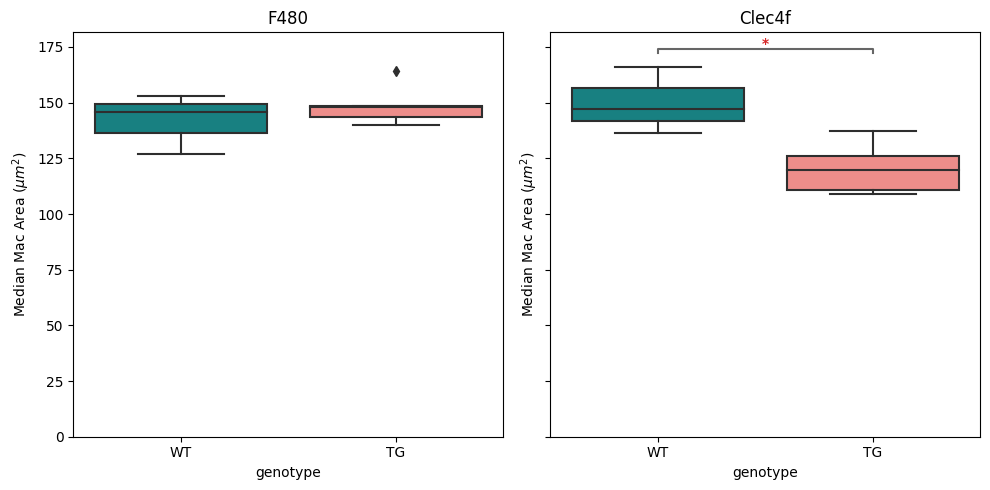

In [64]:
# sns.boxplot(data=df_vsig4, x="genotype", y="median_kc_area")
import numpy as np
from scipy.stats import ttest_ind

def p_to_stars(p):
    if p < 1e-4: return "*****"   # match your figure
    if p < 1e-3: return "****"
    if p < 1e-2: return "***"
    if p < 5e-2: return "*"
    return f"p={p:.3g}"

def add_sig_bracket(ax, x1, x2, y, h, text, color="tab:red", lw=1.5):
    """
    Draws a significance bracket between x1 and x2 (category indices).
    y is baseline height, h is bracket height. `text` is the label above.
    """
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=lw, c="black", alpha=0.6)
    ax.text((x1+x2)/2, y+h, f"$\\bf{{{text}}}$", ha='center', va='bottom', color=color, fontsize=10)

palette_common = {"WT": wt_color, "TG": tg_color, "External CTL": "lightgray"}

fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharey=True)

# -------- F4/80 (no bracket) --------
order_f = ["WT", "TG"]
sns.boxplot(data=df_f480, x="genotype", y="median_kc_area",
            ax=axes[0], order=order_f, palette=palette_common)
axes[0].set_ylabel("Median Mac Area ($\mu m^2$)")
axes[0].set_title("F480")

# -------- VSIG4 (ONLY WT–TG) --------
df_vsig4_combined_prox = pd.concat(
    [df_vsig4[['genotype','median_kc_area']]])
    #  df_control[['genotype','median_kc_area']]], ignore_index=True)

order_v = ["External CTL", "WT", "TG"]
sns.boxplot(data=df_vsig4_combined_prox, x="genotype", y="median_kc_area",
            ax=axes[1], order=order_v, palette=palette_common)

# # fade External CTL
# for i, patch in enumerate(axes[1].patches):
#     if i == 0:
#         patch.set_alpha(0.35)
# for line in axes[1].lines[:6]:
#     line.set_alpha(0.35); line.set_color("gray")

axes[1].set_ylabel("Median Mac Area ($\mu m^2$)")
axes[1].set_title("Clec4f")

# WT vs TG only
a = df_vsig4_combined_prox.loc[df_vsig4_combined_prox.genotype=="WT", "median_kc_area"]
b = df_vsig4_combined_prox.loc[df_vsig4_combined_prox.genotype=="TG", "median_kc_area"]
p = ttest_ind(a, b, equal_var=True, alternative='greater', nan_policy="omit").pvalue

ymin, ymax = axes[1].get_ylim()
h = 0.08*(ymax - ymin)
y0 = df_vsig4_combined_prox["median_kc_area"].max() + 0.25*h
add_sig_bracket(axes[1], 1, 2, y0 + 5, 0.35*h, p_to_stars(p), color="tab:red")

# make room for bracket
yl0 = axes[1].get_ylim()
axes[1].set_ylim(yl0[0], yl0[1] + 0.85*h)
axes[0].set_ylim(bottom=0)
axes[1].set_ylim(bottom=0)
plt.tight_layout()